# Deep Learning Capstone Project: Embedding Dimensionality's Effect on Semantic Meaning
Augustin Langlet

# 1. Introduction

## 1.1 Motivation

In NLP, one of the most fundamental tasks is being able to represent words in the form of vector embeddings. Going beyond a simple one-hot representation, ideally these vectors might somehow encode semantic meaning and could be used to understand words and their relationships with each other. I was inspired by that interesting task for this project.

We began to address this in class by using the matrix decomposition of a co-occurence matrix as seen below.

$\text{Vocabulary Size} = \left| V \right| = v$

$\text{Co-occuring Phrases}= \left| P \right| = p$

$$\mathbf{C} =
  \underset{v \times p}{
      \begin{bmatrix}
          c_1^1 & \cdots & c_p^1 \\
          \vdots & \ddots & \vdots \\
          c_1^v & \cdots & c_p^v
      \end{bmatrix}
  }
\simeq
\overset{\mathbf{E}}{
    \underset{v \times d}{
        \begin{bmatrix}
            e_1^1 & \cdots & e_d^1 \\
            \vdots & \ddots & \vdots \\
            e_1^v & \cdots & e_d^v
        \end{bmatrix}
    }
}
\overset{\mathbf{U^\top}}{
    \underset{p \times d}{
        \begin{bmatrix}
            u_1^1 & \cdots & u_d^1 \\
            \vdots & \ddots & \vdots \\
            u_1^p & \cdots & u_d^p
        \end{bmatrix}^{\top}
    }
}
= \tilde{\mathbf{C}}
$$

Matrix $\mathbf{C}$ has rows of word vectors that have their co-occurence counts with other phrases over the entire corpus given a certain context window. However, this matrix is incredibly sparse since most words in the vocabulary are relatively rare. This causes the cosine similarity between most word vectors to be close to $0$, which doesn't help us much with understanding the semantic similarities between words. Hence, we decompose the co-occurence matrix into two lower rank matrices that approximate our original $C$ matrix. We can then use the denser $\mathbf{E}$ matrix for our summarized word embeddings. By decreasing the rank $d$ of our decomposition to something smaller than $\mathbf{C}$, we force similar word vectors to get closer together in this new smaller vector space. This allows us to embed  the meanings of words into these vectors based on their similarities to each other.

All of this is works based on the Distributional Hypothesis in linguistics that supposes that words with similar contexts (or distributions in a corpus) have similar meaning. Somewhat poetically, reducing the amount of data (by decreasing the rank $d$) increases the amount of semantic information we capture in these embeddings. That relationship inspired this project and is the motivation for trying to understand that relationship better.

## 1.2 Hypothesis

I started off with the idea that decreasing the number of dimensions of the word embeddings would summarize semantic information and increase the cosine similarities between similar words. But on the other extreme, if there aren't enough dimensions, completely irrelevant words might be indistinguishable in a smaller vector space. So my initial hypotheses were, as the dimensionality of word embeddings increases:

1.  The cosine similarity of unrelated pairs of words would go from 1 to 0 relatively quickly.
2.  Related pairs would maintain a high similarity at first and eventually converge to 0 at a much higher dimensionality where all vectors become more unique.
3.  Overall, the amount of semantic meaning in the embeddings vaguely follows a bell curve, increasing at first as unrelated words become distinguishable and decreasing after as all cosine similarities converge to 0.



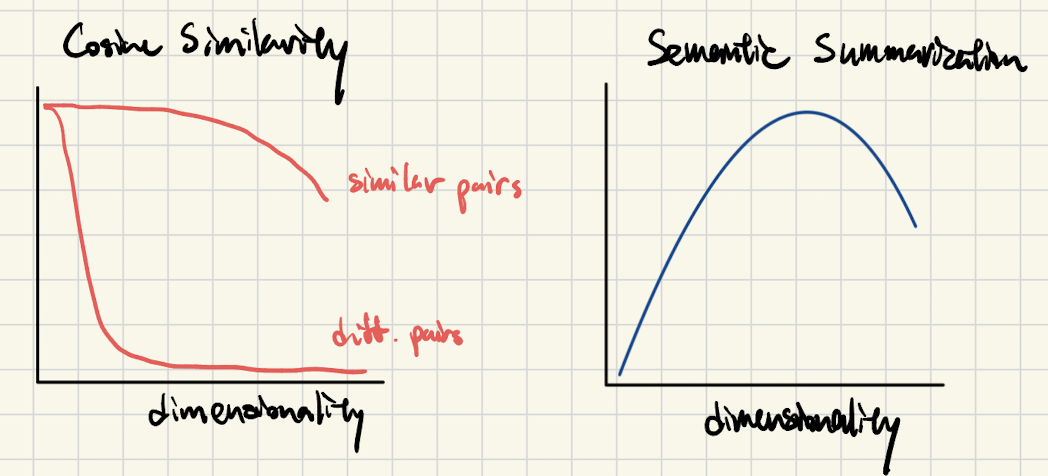

## 1.3 Methods and Process

### Decomposition
To implement these word embeddings through a matrix decomposition, there were three main ways I considered:

1.   **Skip-Gram:** For each target word $w$, training a nueral network with $d$ weights to classify if any given context word $c$ is likely to show up in its context. So training a classifier on $P(+ \mid w, c)$. We can then take the weights of the classifier as the embedding for each word. Models for similar target words will classify context words similarly so we achieve some sort of semantic summarization.
2.   **Stochastic Gradient Descent:** Directly using SGD on the loss function below: $$\mathcal{L} = ||C - \tilde{C}||^2 = \sum_{i,j} (c_i^j - \tilde{c}_i^j)^2$$
3.   **Singular Value Decomposition (SVD):** If we ordered the vectors in the singular value decomposition by the size of the singular values, the first dimensions of the left singular matrix $\mathbf{E}$ capture the axes in $\mathbf{C}$ that have the most variability. So we can truncate the decomposition to approximate $\mathbf{C}$ and take the rows of $\mathbf{E}_{1:d}$ as our word embeddings.

$$
\mathbf{C} = \mathbf{E} \mathbf{\Sigma} \mathbf{V}^{\top}
\simeq
\mathbf{E}_{1:d} \, \mathbf{\Sigma}_{1:d, 1:d} \, \mathbf{V}^{\top}_{1:d}
$$

I ended up picking SVD because scaling the dimensions only requires slicing the matrix instead of recalculating a new matrix from scratch and prevents any inconsistencies from the stochastic nature of the other methods.

### Modifications

After initially using the vectors created from running SVD on the raw co-occurrence counts, results of actual word relations captured were very weak or noisy and inconsistent. This is in part due to the large skew of raw occurence counts towards the top few frequent words like "the", "of", "in", "to" etc.

After reading through some academic resources, I decided to construct a Positive Pointwise Mutual Information matrix like described in [this resource from Dan Jurafsky](https://web.stanford.edu/~jurafsky/li15/lec3.vector.pdf).

$$\text{PPMI}(word_1, word_2) = \max\left(\log_2 \frac{P(word_1, word_2)}{P(word_1)P(word_2)}, 0\right)$$

The point of the function is:
1. The inside ratio of probabilities gives us a value centered at 1 for if a specific word to context pair appears more frequently than if they were independent, giving us a proxy for how related they are.
2. The log centers the neutral value at $log(1) = 0$ and dampens the effect of very large or small ratios which are common with co-occurrence counts.
3. The max extracts only the positive part of the PMI because unrelatedness between words is supposedly harder to understand and overcomplicates things.

The result is a matrix with more balanced information on which words are related to each other. Combined also with an initial Add-1 smoothing to the values to prevent outlier ratios from rare words, this substantially improved the legibility of results in the final analysis.

### Dataset

Since this project is primarily focused on the mechanism of vector embedding dimensionality instead of creating the best possible embeddings, I used the Brown corpus' "News" category containing roughly 10,000 words. I also limited the SVD to the maximum vocabulary size of the top 5000 words within that. The nature of the corpus also dictating the word pair choices I made later on to test the embeddings.

### Verifying and Testing Results

To test the hypotheses, I plotted the cosine similarities _(formula below)_ of different words (related and unrelated) against one benchmark word to see how the similarity changed as the dimensionality of the vectors increased.

$$ \text{cosine similarity}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{ \left\| \mathbf{u} \right\|_2 \left\| \mathbf{v} \right\|_2} $$

Another test and visualization I wanted to try was inspired by the plots in [Mikolov et al. 2013](https://arxiv.org/pdf/1310.4546) as seen below. I tried doing this by taking a subset of word pairs with similar relationships (like present vs past tense verbs) and use PCA and plot the first two dimensions to see if some axis existed that captured the semantic relationship between the word pairs.

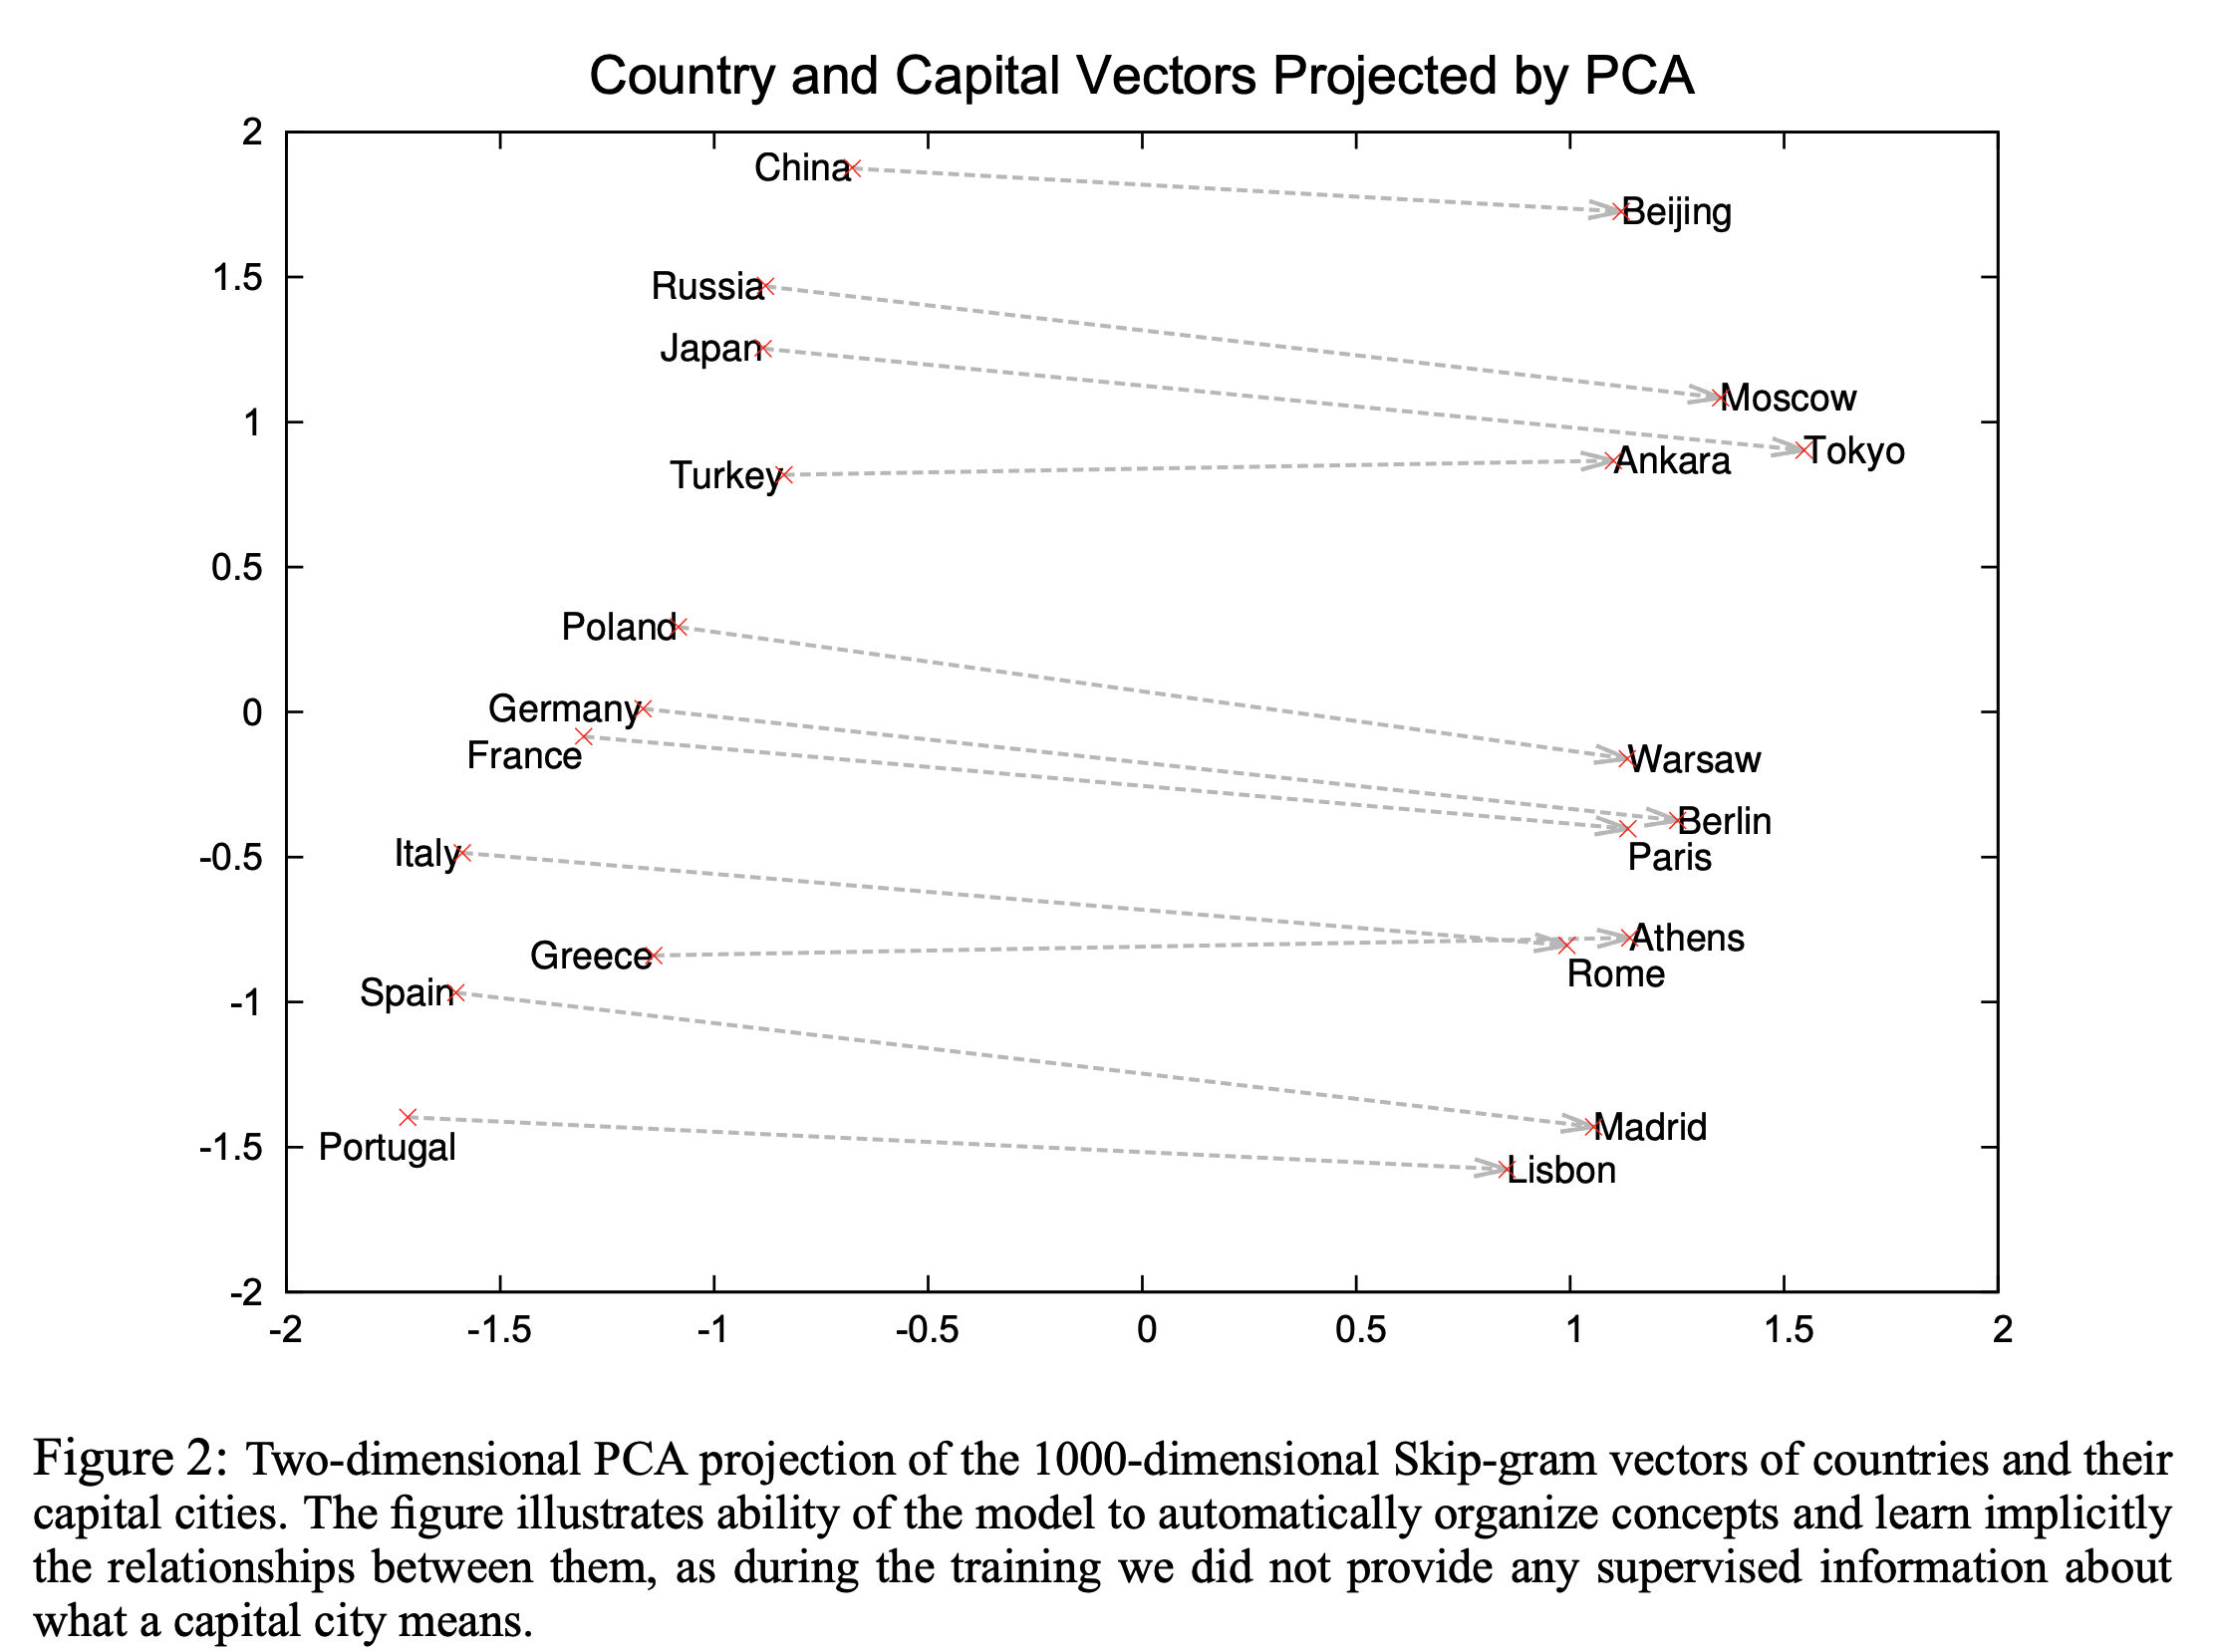

# 2. Building the Model

## 2.1 Preprocessing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.corpus import brown

from scipy.linalg import svd
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
nltk.download('brown')

words = list(brown.words(categories='news'))
print(f"Length of Corpus Used: {len(words)}")
# print(words[:10])

tokens = [w.lower() for w in words if w.isalpha()]

# Keep 5000 most common words
counts = Counter(tokens)
vocab = [w for w, c in counts.most_common(5000)]
print(counts.most_common(10))
print(f"Number of words in corpus: {len(vocab)}")

# mapping useful for creating co-occurence matrix and plotting
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in enumerate(vocab)}

[nltk_data] Downloading package brown to
[nltk_data]     /Users/augustinlanglet/nltk_data...
[nltk_data]   Package brown is already up-to-date!


Length of Corpus Used: 100554
[('the', 6386), ('of', 2861), ('and', 2186), ('to', 2144), ('a', 2130), ('in', 2020), ('for', 969), ('that', 829), ('is', 733), ('was', 717)]
Number of words in corpus: 5000


In [5]:
vocab_size = len(vocab)
co_occurrence_matrix = np.zeros((vocab_size, vocab_size))

print(f"Co-occurrence matrix shape: {co_occurrence_matrix.shape}")

window_size = 4

for i, word in enumerate(tokens):
  if word in word2idx:
    word_idx = word2idx[word]
    start_index = max(0, i - window_size)
    end_index = min(len(tokens), i + window_size + 1)

    for j in range(start_index, end_index):
        context_word = tokens[j]
        if (context_word in word2idx) and (i != j): # if context word is not target word itself
          context_idx = word2idx[context_word]
          co_occurrence_matrix[word_idx, context_idx] += 1

print(co_occurrence_matrix[:5,:5])
print(co_occurrence_matrix[-5:,-5:])

Co-occurrence matrix shape: (5000, 5000)
[[2624. 2531. 1149. 1295.  784.]
 [2531.  464.  599.  347.  645.]
 [1149.  599.  314.  347.  368.]
 [1295.  347.  347.  330.  419.]
 [ 784.  645.  368.  419.  274.]]
[[0. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


## 2.2a SVD on Raw Counts

In [6]:
U, S, Vh = svd(co_occurrence_matrix)

print(f"U Matrix Shape: {U.shape}")

U Matrix Shape: (5000, 5000)


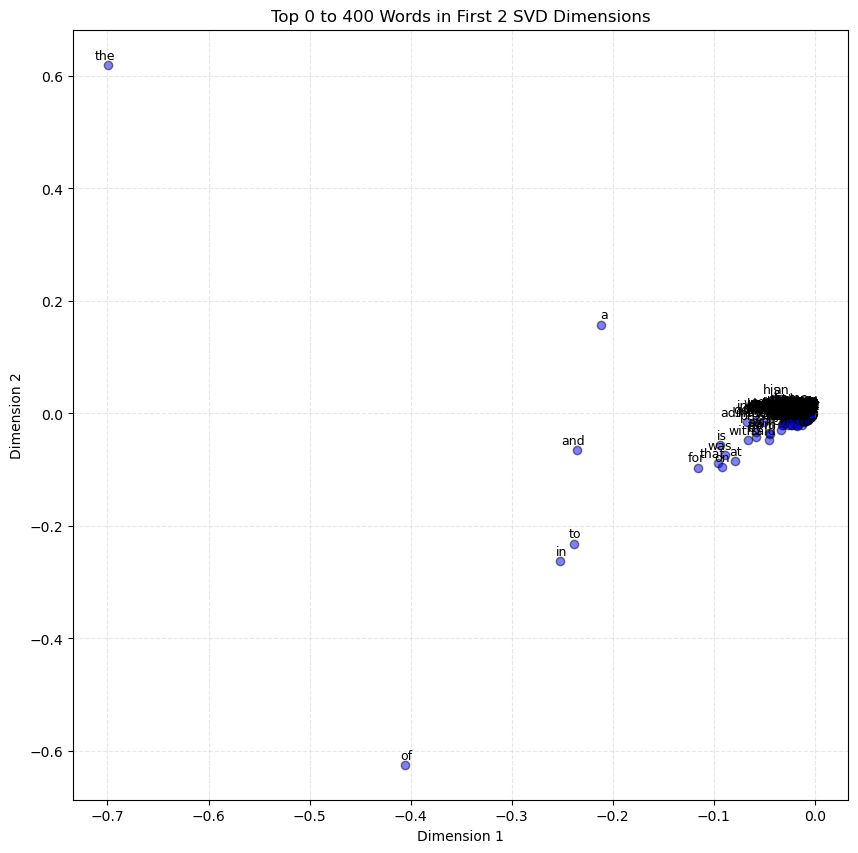

In [7]:
def plot_words_in_range(U_matrix, idx2word, range_start=0, range_end=200):
    # 2D coordinate for ploting words in range in first 2 dimensions of global SVD
    coords = U_matrix[range_start:range_end + 1,:2]

    plt.figure(figsize=(10, 10))
    plt.scatter(coords[:, 0], coords[:, 1], alpha=0.5, c='blue', edgecolors='k')

    for i in range(range_start, range_end + 1):
        relative_index = i - range_start # relative in range
        word = idx2word[i]
        x = coords[relative_index, 0]
        y = coords[relative_index, 1]

        plt.annotate(word,
                     xy=(x, y),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom',
                     fontsize=9)

    plt.title(f"Top {range_start} to {range_end} Words in First 2 SVD Dimensions")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

plot_words_in_range(U, idx2word, 0, 400)

## 2.2b SVD on PPMI

In [8]:
def compute_ppmi(M, alpha=0.75):
    # smoothing, also prevents log(0)
    matrix = M.copy()
    matrix += 1

    # Weighted PMI with alpha
    total_count = np.sum(matrix)
    row_probs = np.sum(matrix, axis=1) / total_count

    col_counts = np.sum(M, axis=0)
    col_weights = col_counts ** alpha
    col_probs = col_weights / np.sum(col_weights)

    # Independent probability matrix (P(w) * P_a(c))
    expected_probs = np.outer(row_probs, col_probs)

    # Joint probability matrix P(w,c)
    joint_probs = matrix / total_count

    # PPMI
    ratio = joint_probs / expected_probs
    pmi = np.log2(ratio)

    ppmi_matrix = np.maximum(0, pmi)
    return ppmi_matrix

ppmi_matrix = compute_ppmi(co_occurrence_matrix)

print(f"PPMI Matrix Shape: {ppmi_matrix.shape}")
print(ppmi_matrix[:5,:5])
print(f"Max PPMI value: {np.max(ppmi_matrix):.3f}")

PPMI Matrix Shape: (5000, 5000)
[[1.00393097 1.83809943 1.02171589 1.16120644 0.46068406]
 [1.96733145 0.40856514 1.09855693 0.27974042 1.19496606]
 [1.16412519 1.11173421 0.50438355 0.61517771 0.72249   ]
 [1.3032952  0.29259717 0.61485717 0.50965977 0.87599666]
 [0.60302071 1.2080707  0.72241736 0.87624455 0.28806563]]
Max PPMI value: 3.949


In [9]:
U_ppmi, S2_ppmi, Vh2_ppmi = svd(ppmi_matrix)

print(f"U_ppmi Matrix Shape: {U_ppmi.shape}")

U_ppmi Matrix Shape: (5000, 5000)


In [10]:
print(U_ppmi[:5,:5])

[[-0.00049653 -0.00105265 -0.00440622  0.0127613  -0.01727324]
 [-0.00208037  0.02605618  0.05059802 -0.04971427 -0.00189434]
 [-0.0032362   0.04044218  0.20817283  0.11471678  0.05649734]
 [-0.00229747 -0.01556624 -0.14642905 -0.21339903 -0.06327105]
 [-0.00264541  0.00131018 -0.07345814  0.18048156 -0.04208597]]


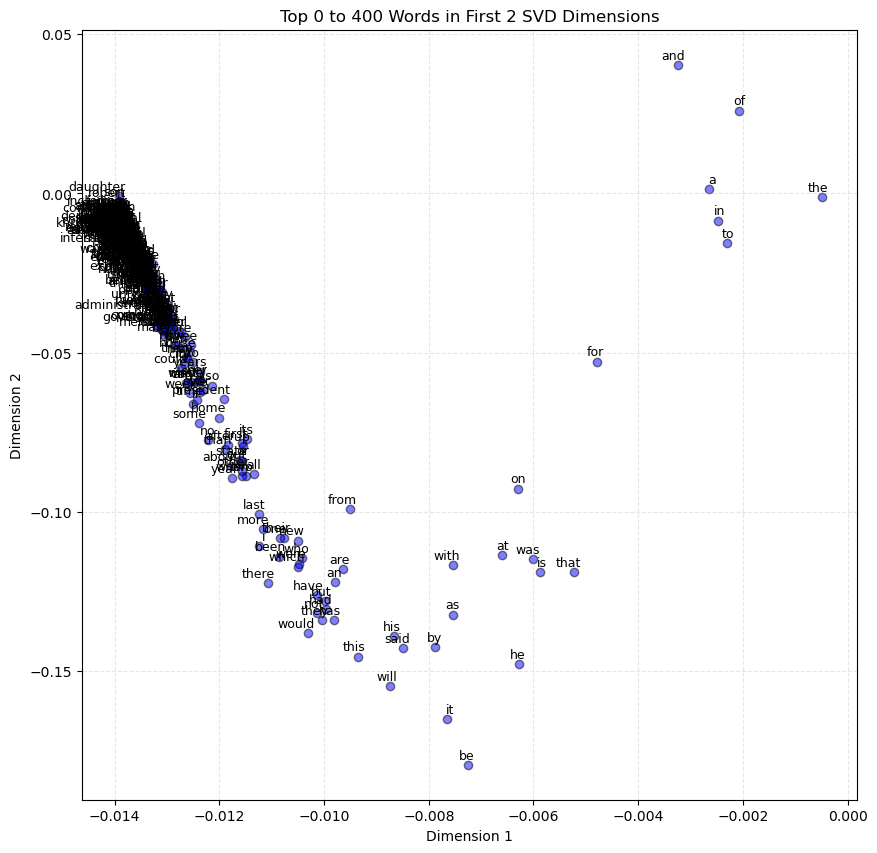

In [11]:
plot_words_in_range(U_ppmi, idx2word, 0, 400)

Just from the visualization of the first two dimensions of embeddings created by the ranked SVD, the distribution of vectors is a lot more balanced using the PPMI matrix as compared to the raw counts.

# 3. Testing the Hypotheses

## 3.1 Creating Test Pairs and Verifying

In [12]:
def get_cosine_similarity(word1, word2, U=U, embedding_size=vocab_size):
    word1_embedding = U[word2idx[word1], :embedding_size].reshape(1, -1)
    word2_embedding = U[word2idx[word2], :embedding_size].reshape(1, -1)

    similarity = cosine_similarity(word1_embedding, word2_embedding)
    return similarity[0][0]

In [14]:
gender_pairs = [
    ("he", "she"),
    ("man", "woman"),
    ("men", "women"),
    ("husband", "wife"),
    ("father", "mother"),
    ("son", "daughter"),
    ("boy", "girl"),
    ("his", "her"),
]

new_gender_pairs = [
    ("father", "mother"),
    ("son", "daughter"),
    ("uncle", "aunt")
]

plural_pairs = [
    ("year", "years"),
    ("state", "states"),
    ("week", "weeks"),
    ("official", "officials"),
    ("member", "members"),
    ("system", "systems"),
    ("man", "men"),
    ("child", "children")
]

tense_pairs = [
    ("did", "do"),
    ("made", "make"),
    ("took", "take")
]

action_pairs = [
    ("take", "took"),
    ("give", "gave"),
    ("go", "went"),
    ("come", "came"),
    ("find", "found"),
    ("hold", "held"),
    ("meet", "met"),
]

test_pairs = [
    ("president", "king"),
    ("woman", "queen"),
    ("man", "woman"),
    ("king", "queen"),
    ("car", "truck"),
    ("thursday", "friday"),
    ("home", "house"),
    ("state", "government"),
    ("president", "administration"),
    ("war", "peace")
]

In [15]:
def verify_pairs(pairs):
  for pair in pairs:
    word1, word2 = pair
    if word1 in word2idx and word2 in word2idx:
      cosine = get_cosine_similarity(word1, word2, U=U_ppmi, embedding_size=100)
      print(f"Valid Pair: ({word1}, {word2})   \tcosine similarity: {cosine:.3f}")
    else:
      print(f"Invalid Pair: ({word1}, {word2})")
  print("\n")

verify_pairs(action_pairs)
verify_pairs(tense_pairs)
verify_pairs(new_gender_pairs)


Valid Pair: (take, took)   	cosine similarity: 0.315
Valid Pair: (give, gave)   	cosine similarity: 0.029
Valid Pair: (go, went)   	cosine similarity: 0.183
Valid Pair: (come, came)   	cosine similarity: 0.349
Valid Pair: (find, found)   	cosine similarity: 0.374
Valid Pair: (hold, held)   	cosine similarity: 0.049
Valid Pair: (meet, met)   	cosine similarity: 0.128


Valid Pair: (did, do)   	cosine similarity: 0.219
Valid Pair: (made, make)   	cosine similarity: 0.103
Valid Pair: (took, take)   	cosine similarity: 0.315


Valid Pair: (father, mother)   	cosine similarity: 0.495
Valid Pair: (son, daughter)   	cosine similarity: 0.643
Valid Pair: (uncle, aunt)   	cosine similarity: 0.580




## 3.2 Test: Cosine Similarities' Trend Over Embedding Sizes

In [31]:
def plot_pairs_cosine_sim(pairs, U=U, min_dim=2, max_dim=vocab_size, subtitle=None):
    plt.figure(figsize=(10, 6))
    # dimensions to test
    dims = np.unique(np.logspace(np.log10(min_dim), np.log10(max_dim), num=50).astype(int))

    similarities = []
    # word pairs
    for i in range(len(pairs)):
        word1, word2 = pairs[i]
        per_pair_similarities = []
        for d in dims:
            sim = get_cosine_similarity(word1, word2, U=U, embedding_size=d)
            per_pair_similarities.append(sim)
        similarities.append(per_pair_similarities)
        pair_label = f"{word1} - {word2}"

        # plot pair
        plt.plot(dims, similarities[i], marker='o',
                 linestyle='-', linewidth=2, markersize=5, label=pair_label)

        # Start and end similarities
        plt.text(dims[0], similarities[i][0], f"{similarities[i][0]:.2f}", va='bottom')
        plt.text(dims[-1], similarities[i][-1], f"{similarities[i][-1]:.2f}", va='bottom')


    #reference line
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

    plt.suptitle("Cosine Similarities by Pair from Left Singular Matrix", fontsize=14)
    if subtitle:
        plt.title(subtitle, fontsize=10, color='dimgray')
    plt.xlabel("Embedding Size (Dimensions); |V|=5000")
    plt.ylabel("Cosine Similarity")

    plt.xscale('log')
    target_ticks = [2, 10, 100, 1000, vocab_size]
    plt.xticks(target_ticks, [str(t) for t in target_ticks])
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()

test1_plotting_pairs = [
    ("president", "king"),
    ("president", "man"),
    ("president", "food"),
    ("president", "government")
]

### Plotting Cosine Similarities from Raw Count-Derived Embeddings

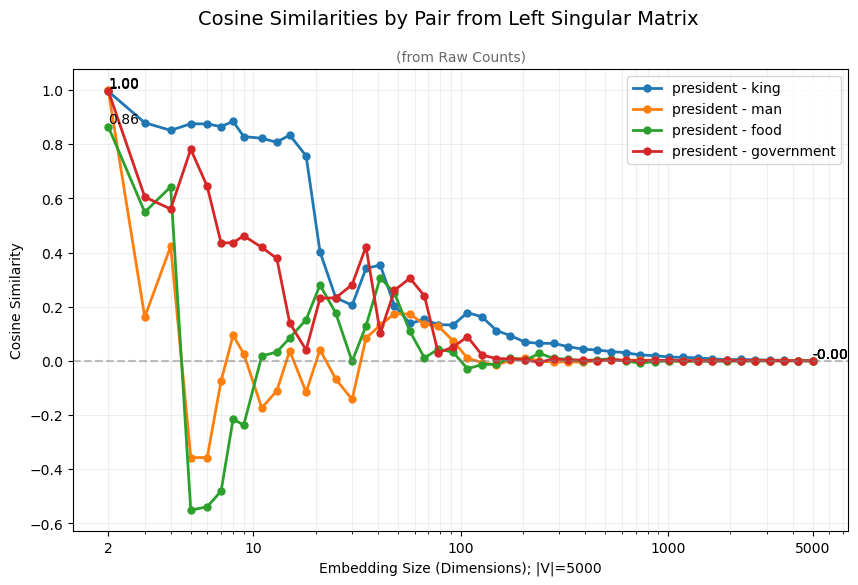

In [32]:
plot_pairs_cosine_sim(test1_plotting_pairs, subtitle="(from Raw Counts)")

### Plotting Cosine Similarities from PPMI-Derived Embeddings

These show substantially more stable and consistent cosine similarities, demonstrating that modifications more reliably capture semantic relationships.

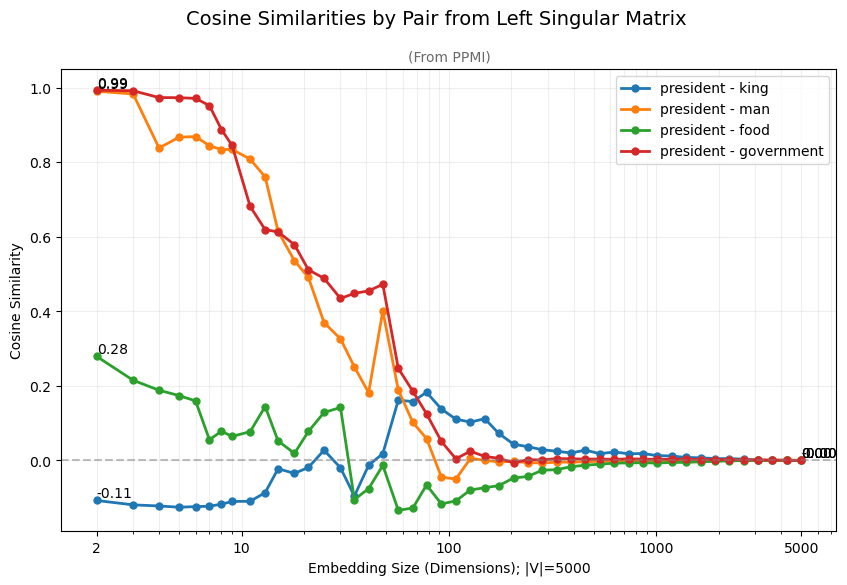

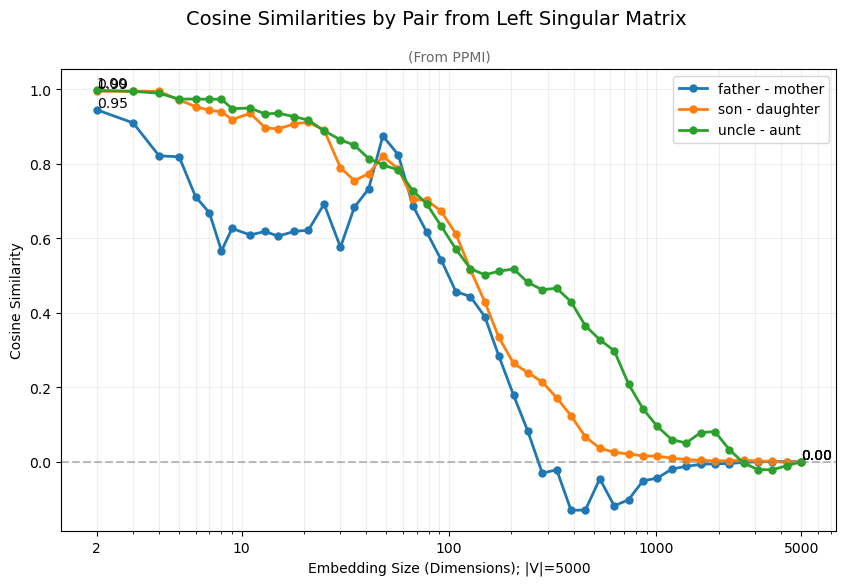

In [33]:
plot_pairs_cosine_sim(test1_plotting_pairs, U=U_ppmi, subtitle="(From PPMI)")
plot_pairs_cosine_sim(new_gender_pairs, U=U_ppmi, subtitle="(From PPMI)")

## 3.3 Test: Relational Semantic Analogies

In [18]:
def plot_pairs(pairs, U=U, embedding_size=vocab_size):
    for pair in pairs:
        word1, word2 = pair

    words_to_plot = []
    embedding_vectors = []

    for word1, word2 in pairs:
        words_to_plot.append(word1)
        words_to_plot.append(word2)
        word1_embedding = U[word2idx[word1], :embedding_size]
        word2_embedding = U[word2idx[word2], :embedding_size]
        embedding_vectors.append(word1_embedding)
        embedding_vectors.append(word2_embedding)

    # PCA on subset of words from pairs
    X = np.array(embedding_vectors)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, c='blue', edgecolors='k')

    # Draw lines and labels for each pair
    for word1, word2 in pairs:
        idx1 = words_to_plot.index(word1)
        idx2 = words_to_plot.index(word2)

        x1, y1 = X_pca[idx1]
        x2, y2 = X_pca[idx2]

        # Line between pairs
        plt.plot([x1, x2], [y1, y2], alpha=0.5, c="grey", linestyle='--')

        # Word Labels
        plt.text(x1, y1, word1, fontsize=12, ha='right', va='bottom', color='black')
        plt.text(x2, y2, word2, fontsize=12, ha='left', va='top', color='red')


    plt.title(f"Embeddings of Word Pairs in 2D using PCA (Embedding Size: {embedding_size})")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

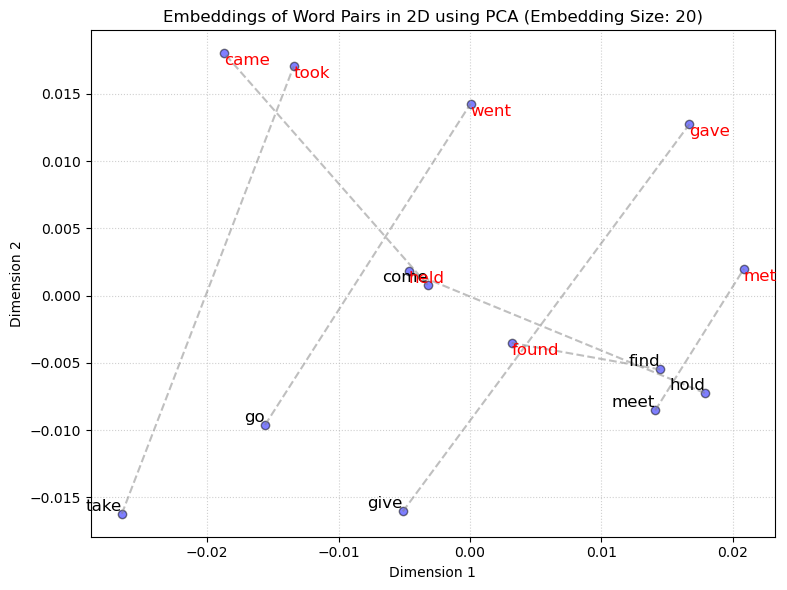

In [19]:
plot_pairs(action_pairs, U=U_ppmi, embedding_size=20)

As seen above, it is possible to find some axes that manage to capture the relations between words like the present and past tense version of words. But these visualizations are very messy I assume due to the limited scale and complexity of this project compared to the one's used in [Mikolov et al. 2013](https://arxiv.org/pdf/1310.4546)

In [20]:
import math
from sklearn.preprocessing import normalize

def plot_pairs_grid(pairs, dims_to_test, U=U, norm=False):

    num_plots = len(dims_to_test)
    cols = 4
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for i, k in enumerate(dims_to_test):
        ax = axes[i]

        words_to_plot = []
        embedding_vectors = []

        for word1, word2 in pairs:

            words_to_plot.extend([word1, word2])
            vec1 = U[word2idx[word1], :k]
            vec2 = U[word2idx[word2], :k]

            embedding_vectors.extend([vec1, vec2])

        X = np.array(embedding_vectors)
        if norm:
          X = normalize(X, norm='l2')

        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)

        ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, c='blue', edgecolors='k')

        # Draw lines and labels for each pair
        for word1, word2 in pairs:
            idx1 = words_to_plot.index(word1)
            idx2 = words_to_plot.index(word2)

            x1, y1 = X_pca[idx1]
            x2, y2 = X_pca[idx2]

            # Line between pairs
            ax.plot([x1, x2], [y1, y2], alpha=0.5, c="grey", linestyle='--')

            # Word Labels
            ax.text(x1, y1, word1, fontsize=12, ha='right', va='bottom', color='black')
            ax.text(x2, y2, word2, fontsize=12, ha='left', va='top', color='red')
        ax.set_title(f"Dim: {k}")
        ax.grid(True, linestyle=':', alpha=0.4)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

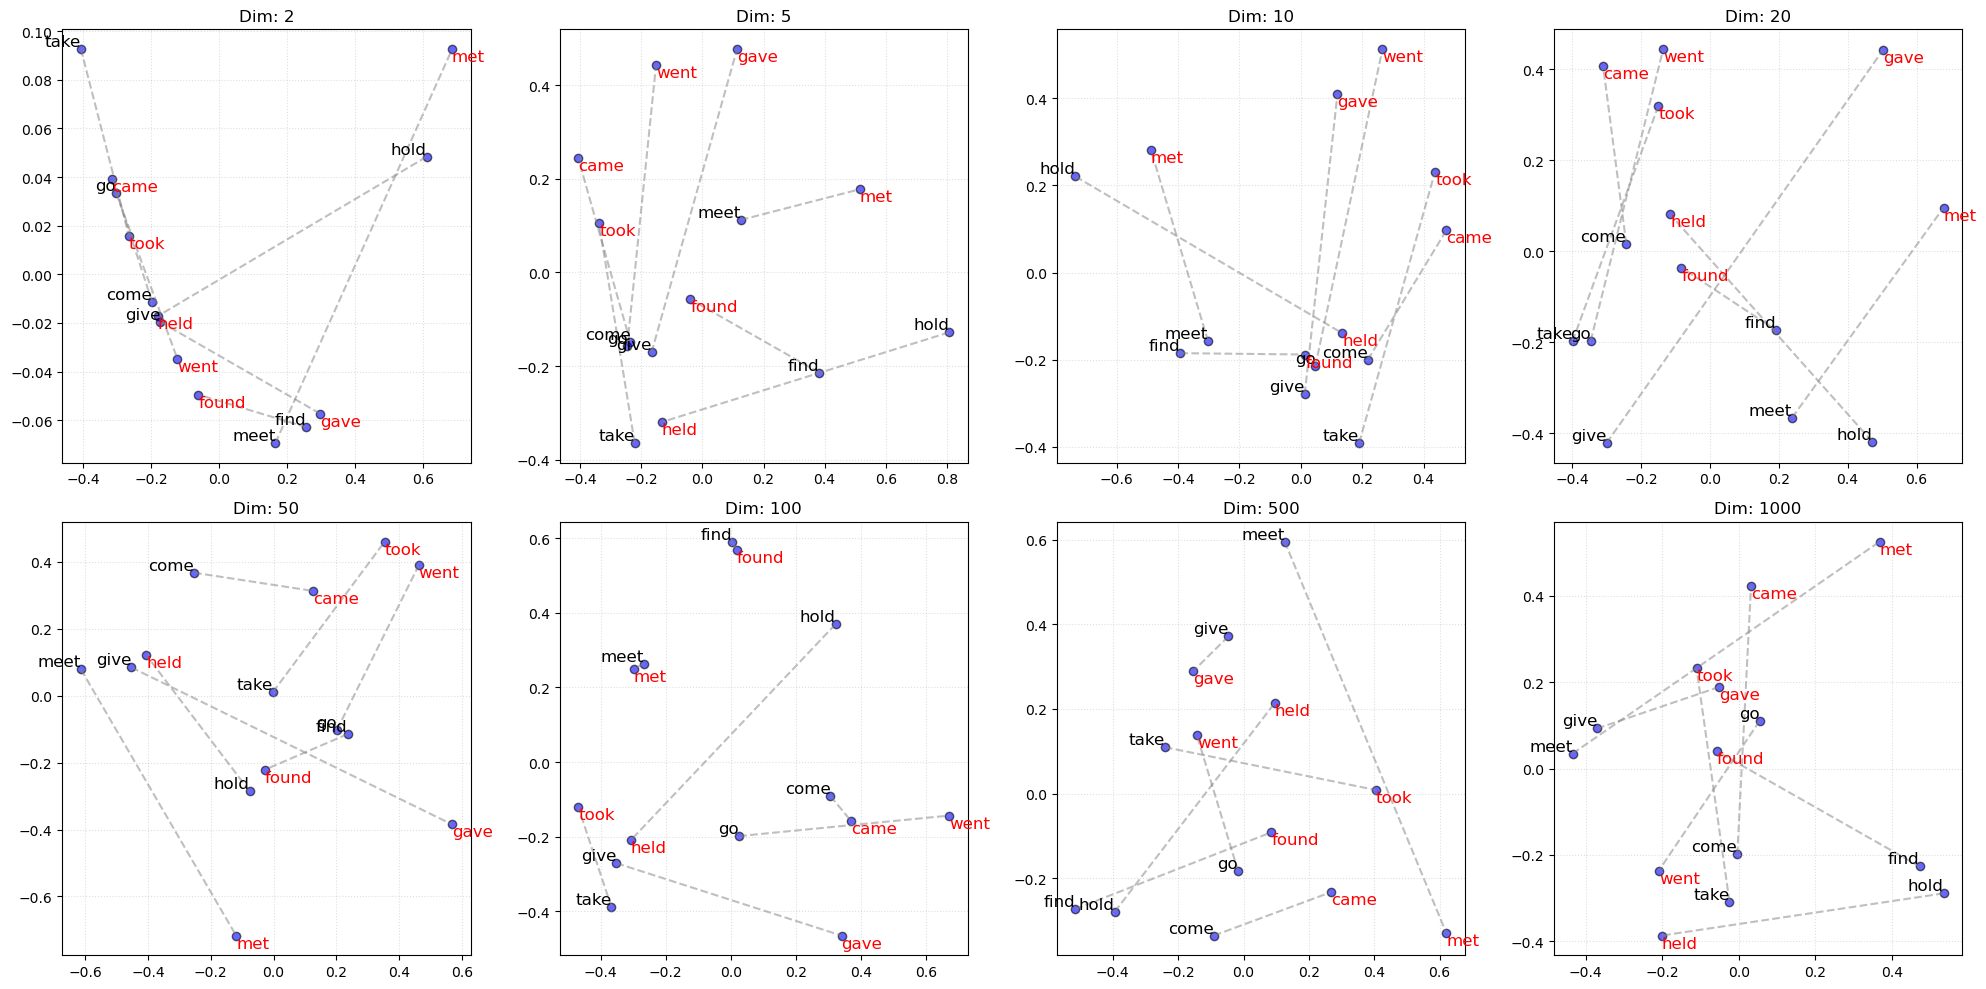

In [21]:
target_dims = [2, 5, 10, 20, 50, 100, 500, 1000]
plot_pairs_grid(action_pairs, target_dims, U=U_ppmi, norm=True)


There does seem to be a middle ground where PCA best captures the semantic relationships across words, again pointing towards the tradeoff of underfiting at low dimensions and losing all semantic summarization at higher dimensions.

# 4. Conclusion

Overall this project gave me a much better understanding of the mechanisms behind word vector embeddings and how they manage to capture semantic information, especially the tradeoff involved between summarizing meaning and distinguishability. 

**The specific key learning points from this project were:**

1. Cosine similarity does more or less behave in the way I expected! Pairs with similar meaning have high cosine similarity and they slowly drop with higher dimensionality until everything converges to 0. Irrelevant words might start with high cosine similarity due to underfitting and oversimplification of the co-occurrence matrix at lower dimensions (like if they are similarly rare or are both nouns). But they quickly drop as dimensions increase.

2. Cosine similarity did not drop smoothly, especially for raw co-occurrence counts. They had random jumps up and down. But ultimately converged to 0.

3. PMI demonstratively reduced the randomness in cosine similarity and skew from common words in both tests to create more stable representations with more semantic meaning captured.

4. The second test on relational analogies produced messier results. Most of the time it was incredibly hard to consistently visualize any clean relations between words as in the inspiration from Mikolov et al.'s paper. Sometimes relations never appeared and some other times they locked into place at higher dimensions without ever degrading. The opposite also appeared with apparent relations being captured at relatively low dimensions and disappearing very quickly. Overall, a more robust, larger scale model and more methodical curation of test pairs might improve the results.

5. It seems like the SVD is double flipping certain values, making negative left singular vectors. Causing the cosine similarities to become negative. That might be contributing to the randomness and cosine similarities being negative. I will look at how other people have implemented SVD for this to double check if this is an issue in further debugging.


# 5. Appendix & Extra Testing

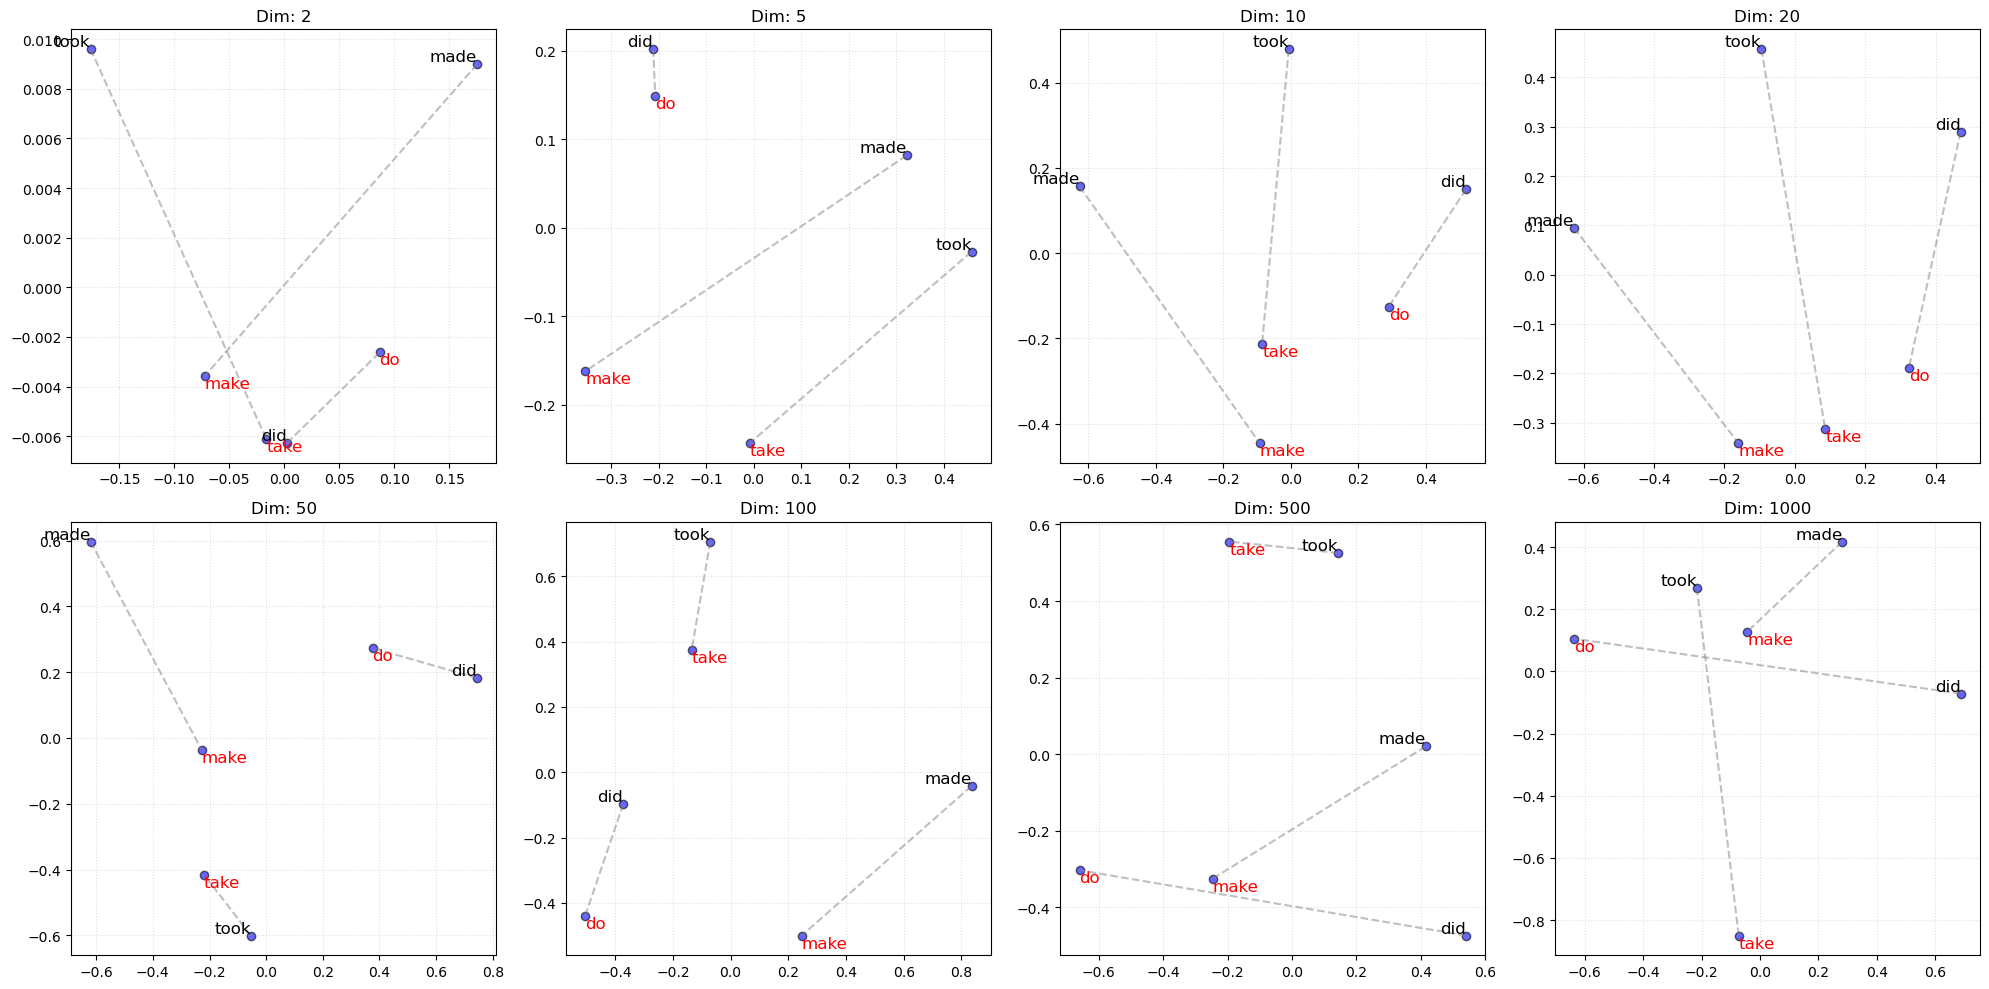

In [ ]:
plot_pairs_grid(tense_pairs, target_dims, U=U_ppmi, norm=True)

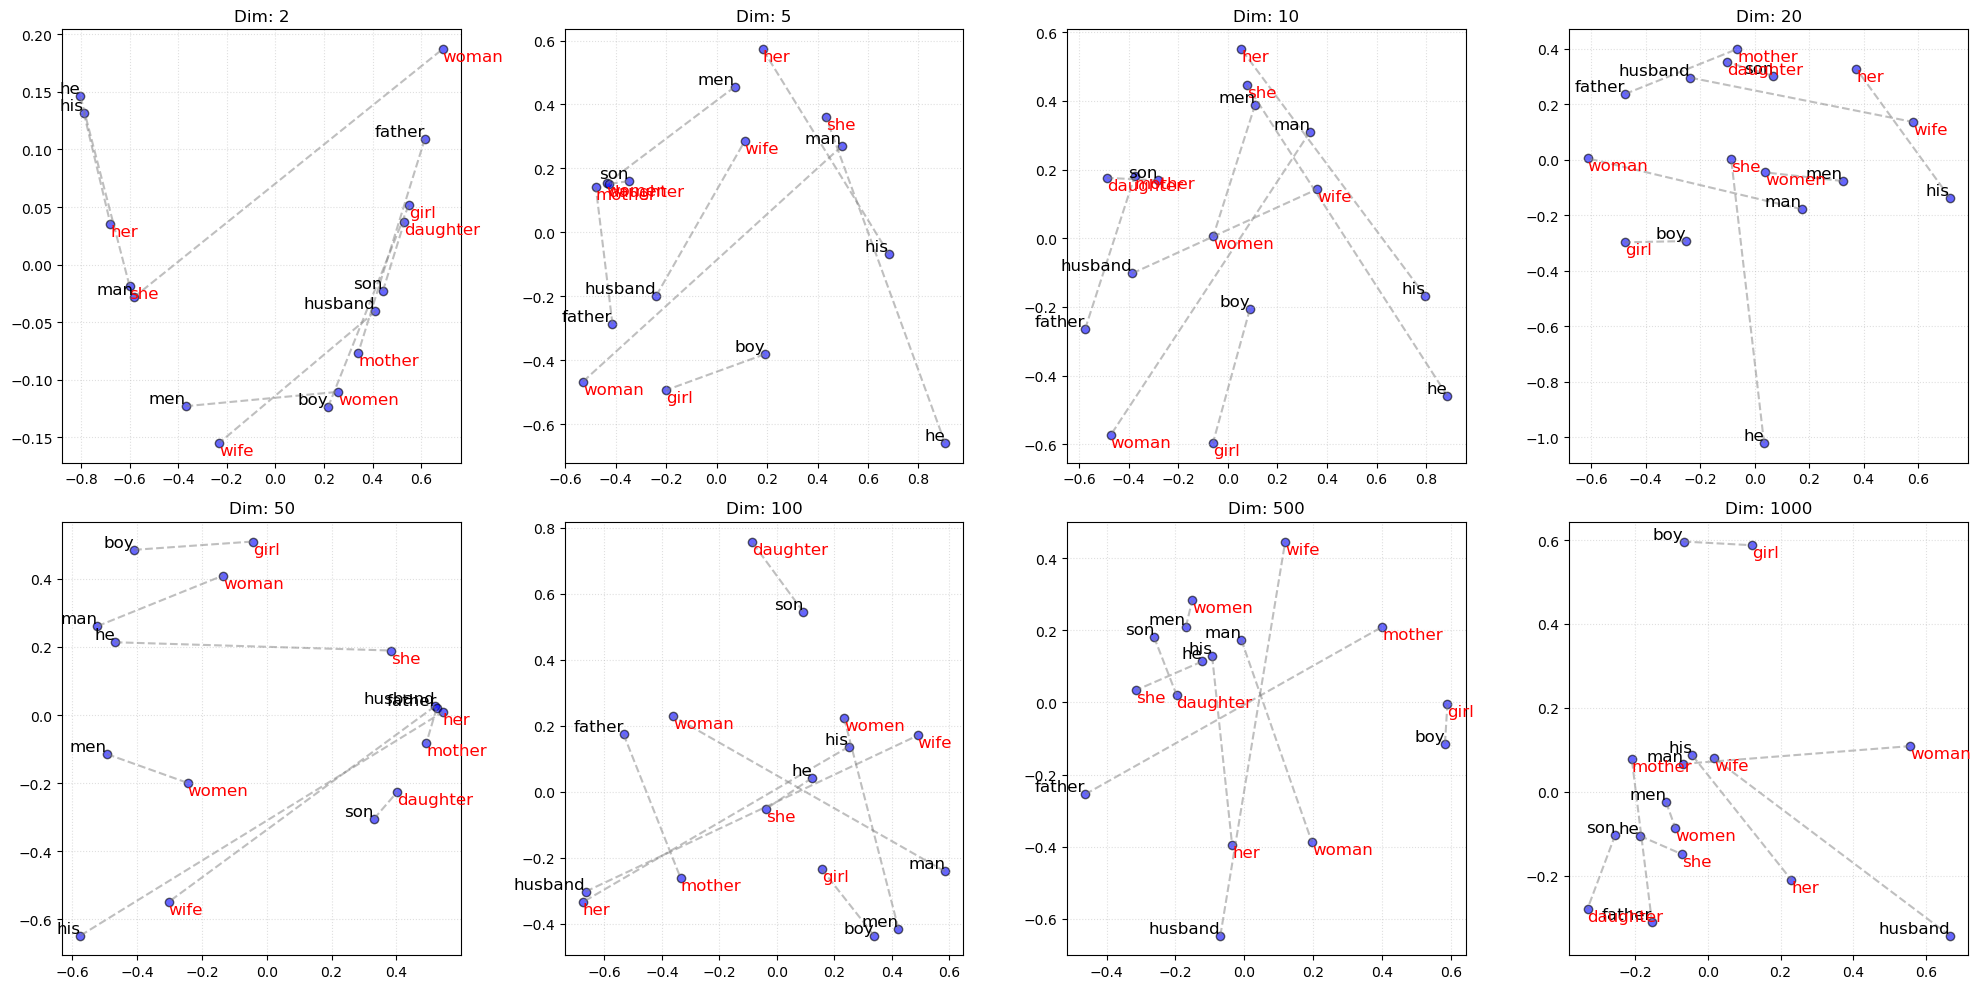

In [ ]:
plot_pairs_grid(gender_pairs, target_dims, U=U_ppmi, norm=True)